# Phase 10: RAG Chain

**Project:** Hospital Patient Helpdesk Chatbot  
**Purpose:** Combine retrieval, safe prompt construction, and provider-neutral generation to create final patient-helpdesk answers with citations.

This notebook imports `06_rag_pipeline/10_rag_chain.py`, which in turn composes the verified Phase 7, Phase 8, and Phase 9 modules. The executable examples use the deterministic offline provider, so validation requires no API key, network connection, or paid model call.


## Inputs and numbered outputs

**Inputs**

- `01_data/sample_queries/test_questions.csv`: synthetic end-to-end questions.
- `05_vector_store/chroma_db/06_vector_index.sqlite3`: searchable hospital evidence.
- `02_config/prompt_config.yaml`: healthcare prompt and insufficient-context policy.
- `.env`: provider and model configuration; credentials are never displayed or persisted.

**Outputs**

- `10_rag_answers.json`: final answers, citations, sources, confidence, safety mode, provider, and stage timings.
- `10_rag_report.json`: aggregate run metrics and artifact inventory.
- `10_rag_audit.csv`: compact operational audit rows.
- `10_failed_rag_answers.json`: sanitized per-question failures.
- `plots/10_rag_stage_latency.png`: stacked retrieval, prompt, and generation latency.
- `plots/10_rag_answer_modes.png`: final grounding and safety-mode counts.


In [1]:
from __future__ import annotations

import importlib.util
import json
import sys
from dataclasses import asdict
from pathlib import Path


def find_project_root(start: Path) -> Path:
    candidates = []
    resolved = start.resolve()
    for directory in (resolved, *resolved.parents):
        candidates.extend((directory, directory / "hospital_patient_helpdesk_chatbot"))
    for candidate in candidates:
        module_path = candidate / "06_rag_pipeline" / "10_rag_chain.py"
        index_path = candidate / "05_vector_store" / "chroma_db" / "06_vector_index.sqlite3"
        if module_path.is_file() and index_path.is_file():
            return candidate
    raise FileNotFoundError("Could not locate the Hospital Patient Helpdesk Chatbot project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
MODULE_PATH = PROJECT_ROOT / "06_rag_pipeline" / "10_rag_chain.py"
QUESTIONS_PATH = PROJECT_ROOT / "01_data" / "sample_queries" / "test_questions.csv"
INDEX_PATH = PROJECT_ROOT / "05_vector_store" / "chroma_db" / "06_vector_index.sqlite3"
PROMPT_CONFIG_PATH = PROJECT_ROOT / "02_config" / "prompt_config.yaml"
OUTPUT_DIR = PROJECT_ROOT / "01_data" / "processed"

spec = importlib.util.spec_from_file_location("phase10_rag_chain", MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load module: {MODULE_PATH}")
rag_chain = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = rag_chain
spec.loader.exec_module(rag_chain)

print(f"Project root: {PROJECT_ROOT}")
print(f"RAG chain module: {MODULE_PATH}")
print(f"Vector index: {INDEX_PATH}")


Project root: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot
RAG chain module: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\06_rag_pipeline\10_rag_chain.py
Vector index: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\05_vector_store\chroma_db\06_vector_index.sqlite3


## Load shared components and configuration

The chain uses each phase through its public interface. Phase 7 owns embedding and retrieval, Phase 8 owns prompt modes and source budgeting, and Phase 9 owns provider access and response validation. The notebook forces `offline` for reproducible execution.


In [2]:
retriever, prompt_builder, llm_client = rag_chain.load_dependencies(PROJECT_ROOT)
embedder, vector_store = retriever.load_dependencies(PROJECT_ROOT)
prompt_settings = prompt_builder.load_prompt_settings(PROMPT_CONFIG_PATH)
environment_values = llm_client.environment(PROJECT_ROOT)
llm_config = llm_client.config_from_environment(environment_values, provider="offline")
chain_config = rag_chain.RAGChainConfig()
questions = rag_chain.load_questions(QUESTIONS_PATH)

print(f"Questions: {len(questions)}")
print(f"Provider: {llm_config.provider}")
print(f"Model: {llm_config.model}")
print(f"Top-k evidence chunks: {chain_config.top_k}")
print("Credentials displayed: no")


Questions: 12
Provider: offline
Model: offline-grounded-v1
Top-k evidence chunks: 3
Credentials displayed: no


## Trace one end-to-end answer

The next cell runs a single appointment question through all three stages. The returned contract includes the final answer, only the citations actually used by the model, the complete source list supplied to the prompt, retrieval confidence, safety labels, and separate stage timings.


In [3]:
sample_answer = rag_chain.answer_question(
    question=questions[0]["question"],
    sequence=1,
    index_path=INDEX_PATH,
    prompt_settings=prompt_settings,
    chain_config=chain_config,
    llm_config=llm_config,
    environment_values=environment_values,
    retriever=retriever,
    prompt_builder=prompt_builder,
    llm_client=llm_client,
    embedder=embedder,
    vector_store=vector_store,
)

print(json.dumps(asdict(sample_answer), indent=2, ensure_ascii=False))


{
  "answer_id": "ANSWER-001",
  "chain_version": "1.0",
  "question": "How can I book an appointment?",
  "answer": "Use the patient portal, call 555-0101, or visit the Appointments Desk. Same-day availability is not guaranteed. [S1]",
  "mode": "grounded_answer",
  "citations": [
    "[S1]"
  ],
  "sources": [
    {
      "citation": "[S1]",
      "chunk_id": "faqs-hospital-faqs-json-0001-chunk-001",
      "source_file": "faqs/hospital_faqs.json",
      "source_type": "json",
      "department": "Portal Support",
      "content_category": "appointments",
      "page_reference": null,
      "score": 0.74580427
    },
    {
      "citation": "[S2]",
      "chunk_id": "faqs-hospital-faqs-json-0003-chunk-001",
      "source_file": "faqs/hospital_faqs.json",
      "source_type": "json",
      "department": "Billing and Insurance",
      "content_category": "appointments",
      "page_reference": null,
      "score": 0.54794383
    },
    {
      "citation": "[S3]",
      "chunk_id": "supp

## Verify safety routing

Emergency and unsafe-medical-advice questions must not continue as ordinary grounded answers. The retriever supplies safety labels, the prompt builder selects the restrictive mode, and the LLM client validates the resulting response.


In [4]:
safety_rows = [
    row for row in questions
    if row.get("safety_class") in {"emergency", "unsafe_medical_advice"}
]

for number, row in enumerate(safety_rows, start=100):
    answer = rag_chain.answer_question(
        row["question"], number, INDEX_PATH, prompt_settings, chain_config,
        llm_config, environment_values, retriever, prompt_builder,
        llm_client, embedder, vector_store,
    )
    print(f"[{answer.mode}] {answer.answer}\n")


[emergency] Contact local emergency services immediately or go to the nearest emergency department. I cannot diagnose the cause of your symptoms.

[unsafe_medical_advice] I cannot diagnose a condition, recommend treatment, or provide a medication dosage. Please contact a qualified clinician or pharmacist.



## Run the complete Phase 10 evaluation

Each question is isolated so one provider or data error does not erase successful answers. The batch writes all `10_` artifacts and creates the diagnostics. Assertions make contract regressions visible in the notebook.


In [5]:
result = rag_chain.run_chain_evaluation(
    questions_path=QUESTIONS_PATH,
    index_path=INDEX_PATH,
    prompt_config_path=PROMPT_CONFIG_PATH,
    output_dir=OUTPUT_DIR,
    project_root=PROJECT_ROOT,
    chain_config=chain_config,
    provider_name="offline",
)

assert result.input_questions == len(questions)
assert result.answers_created == len(questions)
assert result.failed_answers == 0

print(f"Input questions: {result.input_questions}")
print(f"Answers created: {result.answers_created}")
print(f"Failed answers: {result.failed_answers}")
print(f"Answers file: {result.answers_path}")


Input questions: 12
Answers created: 12
Failed answers: 0
Answers file: C:\Users\Prompt\Documents\Hospital Patient Helpdesk Chatbot\hospital_patient_helpdesk_chatbot\01_data\processed\10_rag_answers.json


## Validate final answer contracts

The validation confirms that outputs are non-empty, citations belong to their own source lists, failures are empty, and the expected grounding and healthcare safety modes are represented.


In [6]:
answers = json.loads(result.answers_path.read_text(encoding="utf-8"))
report = json.loads(result.report_path.read_text(encoding="utf-8"))
failures = json.loads(result.failed_path.read_text(encoding="utf-8"))

assert len(answers) == 12
assert failures == []
assert all(item["question"].strip() and item["answer"].strip() for item in answers)
assert all(
    set(item["citations"]).issubset({source["citation"] for source in item["sources"]})
    for item in answers
)
assert report["mode_counts"] == {
    "emergency": 1,
    "grounded_answer": 9,
    "unsafe_medical_advice": 2,
}

print(json.dumps(report, indent=2))


{
  "generated_at_utc": "2026-06-14T20:07:16.681785+00:00",
  "chain_version": "1.0",
  "questions_input": "C:\\Users\\Prompt\\Documents\\Hospital Patient Helpdesk Chatbot\\hospital_patient_helpdesk_chatbot\\01_data\\sample_queries\\test_questions.csv",
  "index_input": "C:\\Users\\Prompt\\Documents\\Hospital Patient Helpdesk Chatbot\\hospital_patient_helpdesk_chatbot\\05_vector_store\\chroma_db\\06_vector_index.sqlite3",
  "prompt_config_input": "C:\\Users\\Prompt\\Documents\\Hospital Patient Helpdesk Chatbot\\hospital_patient_helpdesk_chatbot\\02_config\\prompt_config.yaml",
  "input_questions": 12,
  "answers_created": 12,
  "failed_answers": 0,
  "provider": "offline",
  "model": "offline-grounded-v1",
  "mode_counts": {
    "emergency": 1,
    "grounded_answer": 9,
    "unsafe_medical_advice": 2
  },
  "confidence_counts": {
    "high": 5,
    "medium": 7
  },
  "total_latency_ms": {
    "minimum": 2.739,
    "maximum": 36.139,
    "mean": 8.827,
    "median": 6.9
  },
  "configur

## Diagnostic plots

The stacked latency chart separates retrieval, prompt, and generation time for each question. The mode chart confirms the balance of grounded answers and safety-routed responses. These operational plots do not measure medical correctness.


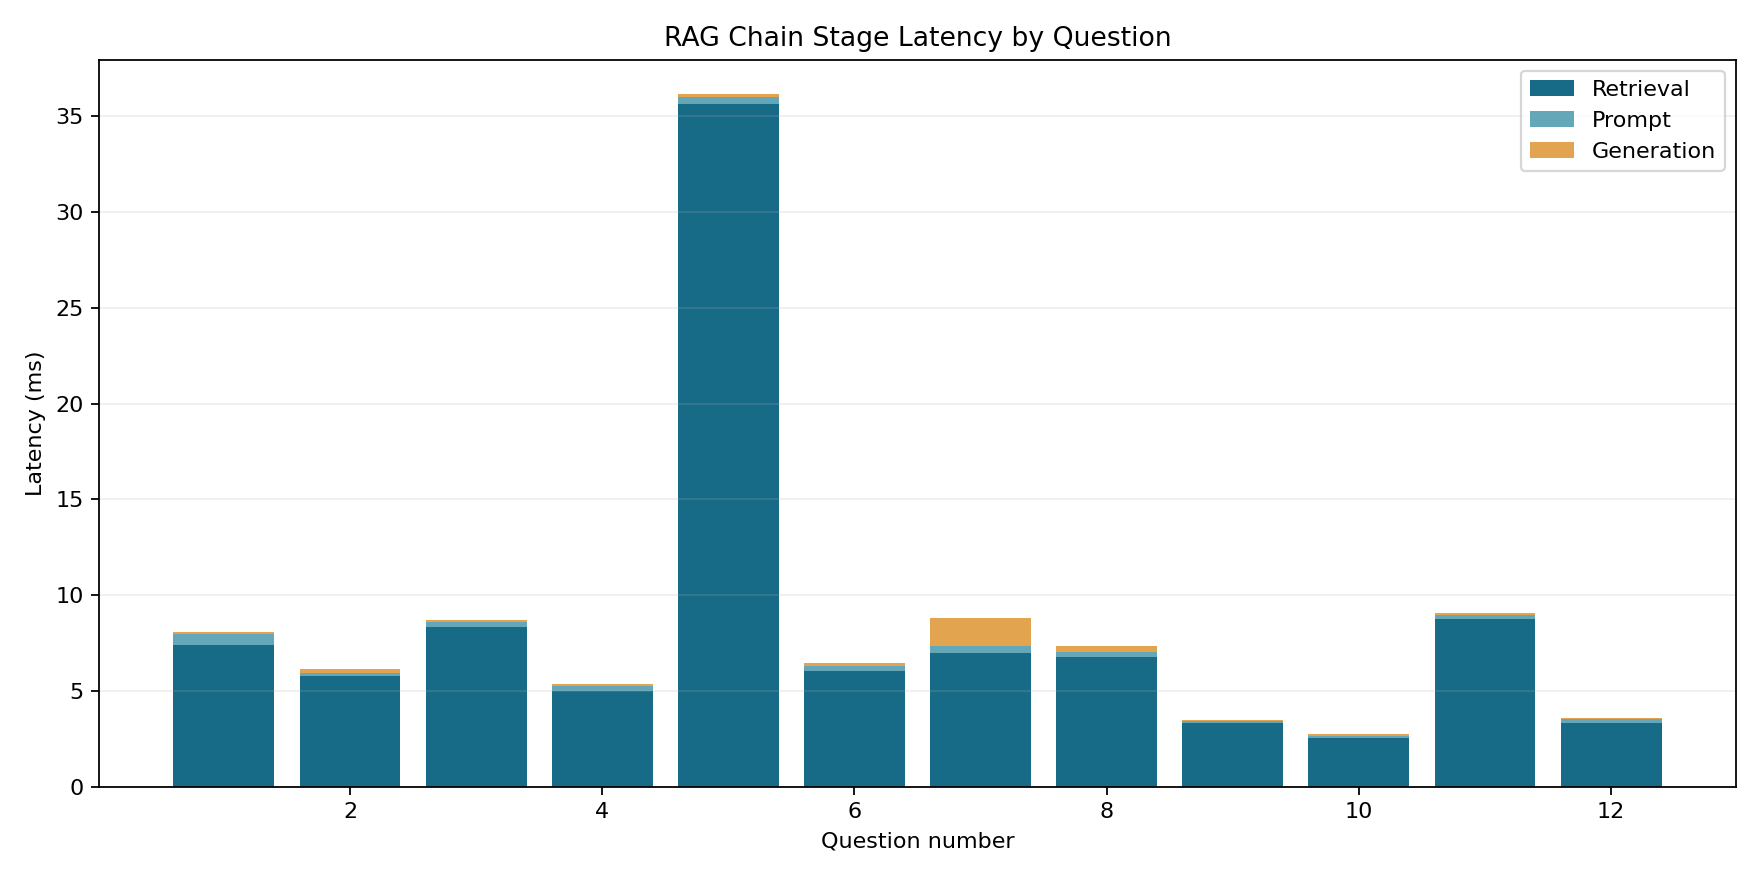

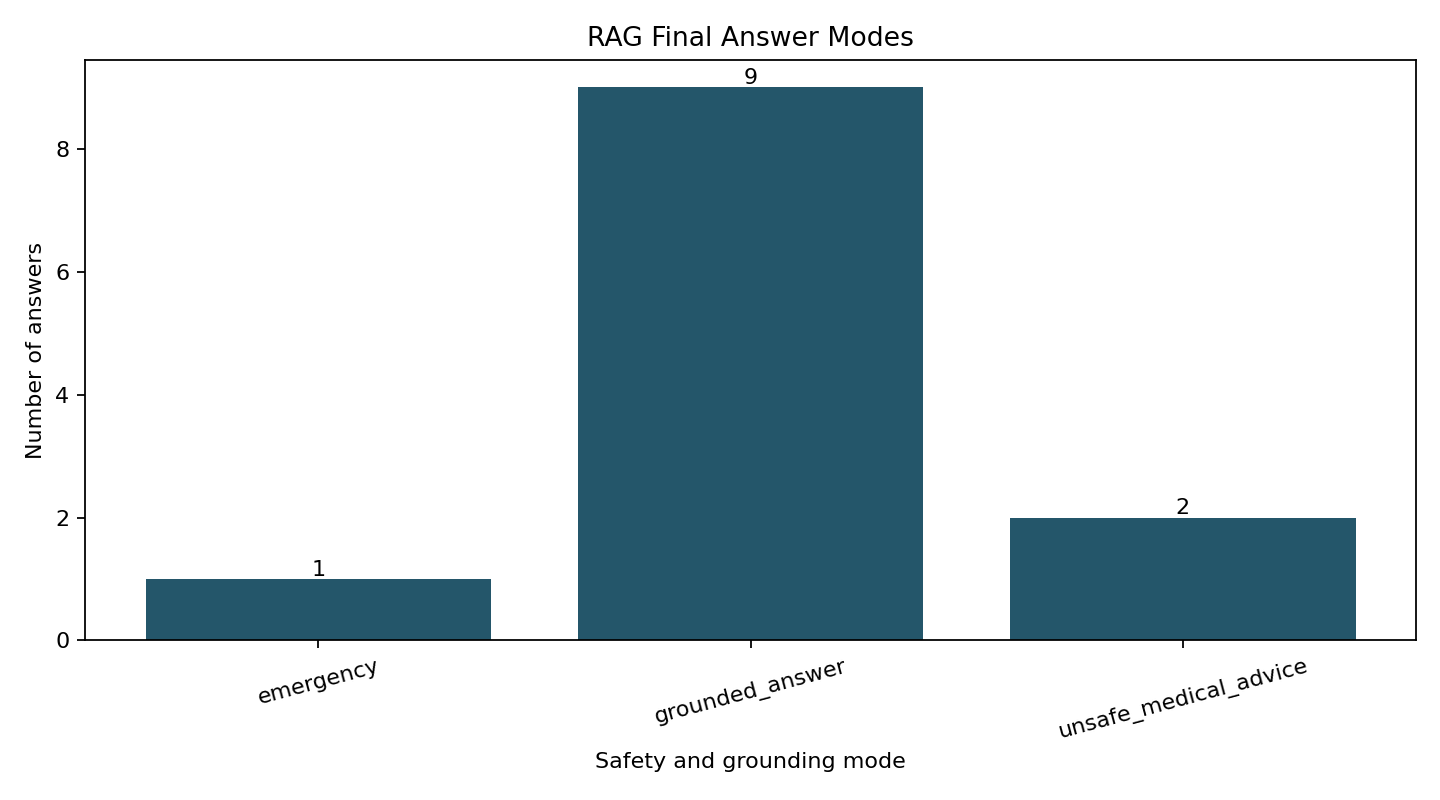

In [7]:
from IPython.display import Image, display

display(Image(filename=str(result.latency_plot_path)))
display(Image(filename=str(result.mode_plot_path)))


## Notebook and Python module responsibilities

- **Notebook:** guided trace, safety demonstrations, assertions, report inspection, and inline plots.
- **Python module:** dependency loading, configuration translation, chain orchestration, validation, failure isolation, output writing, diagnostics, and CLI execution.

Both files run the same implementation. The notebook adds explanation and inspection without copying the production chain logic.

## Safety and privacy boundary

The Phase 10 chain is a hospital information assistant, not a diagnostic system. It must use approved evidence, preserve citations, refuse diagnosis and dosage recommendations, route emergencies to local emergency services, and avoid sending protected health information to an external provider without authorization. Phase 11 adds dedicated guardrails as defense in depth.
